Number of Face Images Loaded: 32
Image: 0520962400.jpg
Skin Pixels: 13636
Skin Percentage: 16.52%
--------------------------------


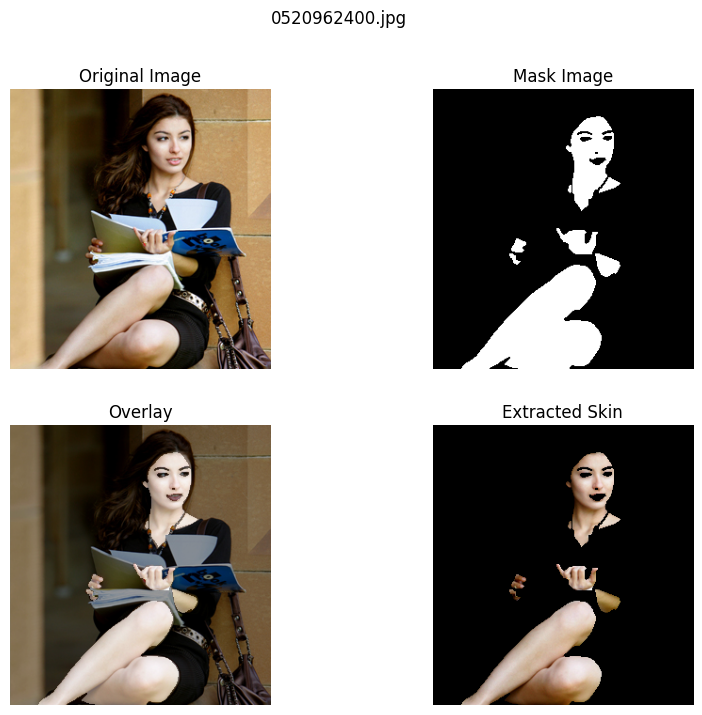

Image: 06Apr03Face.jpg
Skin Pixels: 82792
Skin Percentage: 44.57%
--------------------------------


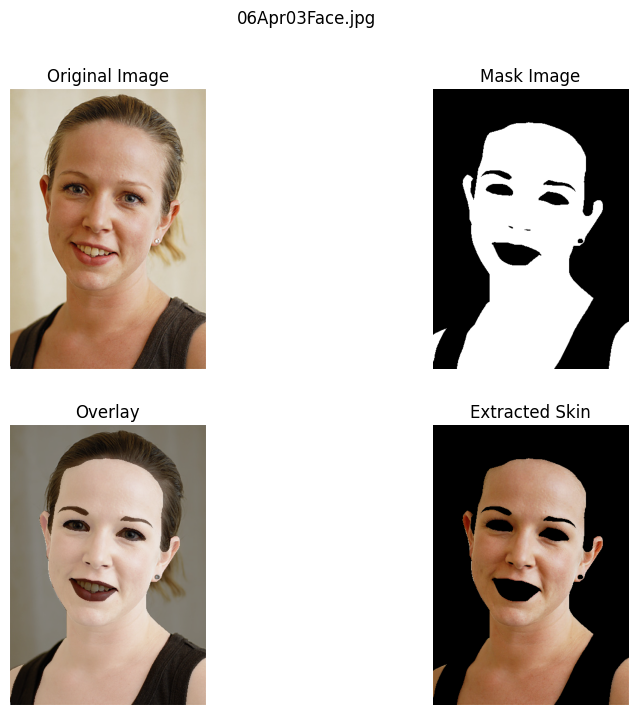

Image: 124511719065943_2.jpg
Skin Pixels: 22176
Skin Percentage: 17.03%
--------------------------------


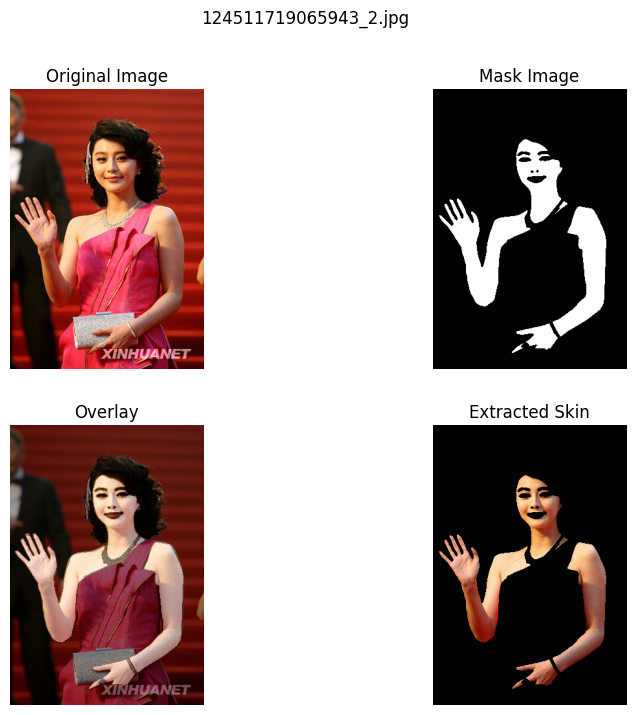

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# Folders
face_dir = r"C:\Users\lenovo\Desktop\IPCV\images\SkinColor\FacePhoto"
mask_dir = r"C:\Users\lenovo\Desktop\IPCV\images\SkinColor\Mask Photo"

images = []
masks = []
names = []

image_files = os.listdir(face_dir)
mask_files = os.listdir(mask_dir)

# Match images with masks
for img_file in image_files:
    name, _ = os.path.splitext(img_file)

    for mask_file in mask_files:
        mask_name, _ = os.path.splitext(mask_file)

        if name == mask_name:
            img_path = os.path.join(face_dir, img_file)
            mask_path = os.path.join(mask_dir, mask_file)

            image = imageio.imread(img_path)
            mask = imageio.imread(mask_path)

            images.append(image)
            masks.append(mask)
            names.append(img_file)
            break

print("Number of Face Images Loaded:", len(images))

# Process images
for i in range(len(images)):

    image = images[i]
    mask = masks[i]
    name = names[i]

    # Ensure mask is RGB
    mask_rgb = mask[:, :, :3]

    # Detect white pixels (skin)
    skin_pixels = np.all(mask_rgb == [255, 255, 255], axis=-1)

    # Extract skin
    skin_image = np.zeros_like(image)
    skin_image[skin_pixels] = image[skin_pixels]

    # Calculate percentage
    total_pixels = skin_pixels.size
    skin_count = np.sum(skin_pixels)
    skin_percentage = (skin_count / total_pixels) * 100

    print("Image:", name)
    print("Skin Pixels:", skin_count)
    print("Skin Percentage: %.2f%%" % skin_percentage)
    print("--------------------------------")

    # Display results
    plt.figure(figsize=(10,8))

    plt.subplot(2,2,1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(2,2,2)
    plt.imshow(mask)
    plt.title("Mask Image")
    plt.axis("off")

    plt.subplot(2,2,3)
    plt.imshow(image)
    plt.imshow(mask, alpha=0.4)
    plt.title("Overlay")
    plt.axis("off")

    plt.subplot(2,2,4)
    plt.imshow(skin_image)
    plt.title("Extracted Skin")
    plt.axis("off")

    plt.suptitle(name)
    plt.show()

    # Show only first 3 images (optional)
    if i == 2:
        break